In [1]:
import pandas as pd
import numpy as np

In [2]:
corpus = [
     'The car is driven on the road',
     'The truck is driven on the highway',     
 ]

### Bag of Words

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

### Unigram

In [5]:
vectorizer = CountVectorizer(ngram_range=(1,1))
X = vectorizer.fit_transform(corpus)
print(X.toarray())

[[1 1 0 1 1 1 2 0]
 [0 1 1 1 1 0 2 1]]


In [6]:
vocab = vectorizer.vocabulary_
vocab

{'the': 6,
 'car': 0,
 'is': 3,
 'driven': 1,
 'on': 4,
 'road': 5,
 'truck': 7,
 'highway': 2}

### Bigram

In [7]:
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(corpus)
print(X.toarray())

[[1 1 1 1 1 0 1 0 0]
 [0 1 1 1 0 1 0 1 1]]


In [8]:
vocab = vectorizer.vocabulary_
vocab

{'the car': 4,
 'car is': 0,
 'is driven': 2,
 'driven on': 1,
 'on the': 3,
 'the road': 6,
 'the truck': 7,
 'truck is': 8,
 'the highway': 5}

### Using a range

In [9]:
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(corpus)
print(X.toarray())

[[1 1 1 1 0 1 1 1 1 1 2 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 0 2 0 1 0 1 1 1]]


In [10]:
vocab = vectorizer.vocabulary_
vocab

{'the': 10,
 'car': 0,
 'is': 5,
 'driven': 2,
 'on': 7,
 'road': 9,
 'the car': 11,
 'car is': 1,
 'is driven': 6,
 'driven on': 3,
 'on the': 8,
 'the road': 13,
 'truck': 15,
 'highway': 4,
 'the truck': 14,
 'truck is': 16,
 'the highway': 12}

## TF - IDF

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
vectorizer = TfidfVectorizer()

tfidf = vectorizer.fit_transform(corpus) 
pd.DataFrame(tfidf.toarray())

,0,1,2,3,4,5,6,7
0,0.424717,0.30219,0.000000,0.30219,0.30219,0.424717,0.60438,0.000000
1,0.000000,0.30219,0.424717,0.30219,0.30219,0.000000,0.60438,0.424717


### Spam Classification

In [14]:
df = pd.read_csv('smsspamcollection.tsv', sep='\t')
df

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,8
5568,ham,Will ü b going to esplanade fr home?,36,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,7
5570,ham,The guy did some bitching but I acted like i'd...,125,1


In [15]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

X = df['message']  
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3733,), (1839,), (3733,), (1839,))

### Convert to numeric using Bag of Words

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()

# Vectors created with BoW
X_train_counts = count_vect.fit_transform(X_train)

In [19]:
X_train_counts

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 49992 stored elements and shape (3733, 7082)>

In [20]:
X_train_counts.shape

(3733, 7082)

### Convert to numeric using TF-IDF

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()

# Vectors created with TF-IDF
X_train_tfidf = vectorizer.fit_transform(X_train) 
X_train_tfidf.shape

(3733, 7082)

### Create Classification model

In [22]:
from sklearn.svm import LinearSVC
clf = LinearSVC()
clf.fit(X_train_tfidf,y_train)

LinearSVC()

In [23]:
predictions = clf.predict(X_train_tfidf)
predictions

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object)

### Create a pipeline

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn import metrics


text_ppl = Pipeline([('tfidf', TfidfVectorizer()),
                     ('clf', RandomForestClassifier()),
])

# Feed the training data through the pipeline
text_ppl.fit(X_train, y_train)  

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', RandomForestClassifier())])

In [25]:
predictions = text_ppl.predict(X_train)
predictions

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object)

In [26]:
# Print the overall accuracy
print(metrics.accuracy_score(y_train, predictions))

1.0


In [27]:
print(metrics.confusion_matrix(y_train,predictions))

[[3232    0]
 [   0  501]]


In [28]:
test_predictions = text_ppl.predict(X_test)

In [29]:
# Print the overall accuracy
print(metrics.accuracy_score(y_test, test_predictions))

0.977705274605764


In [30]:
print(metrics.confusion_matrix(y_test, test_predictions))

[[1593    0]
 [  41  205]]


### Wordcloud

In [1]:
#!pip install wordcloud

In [6]:
from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Returns a string
dataset = open("../../datasets/modi.txt", "r").read()
dataset = dataset.lower()
#dataset

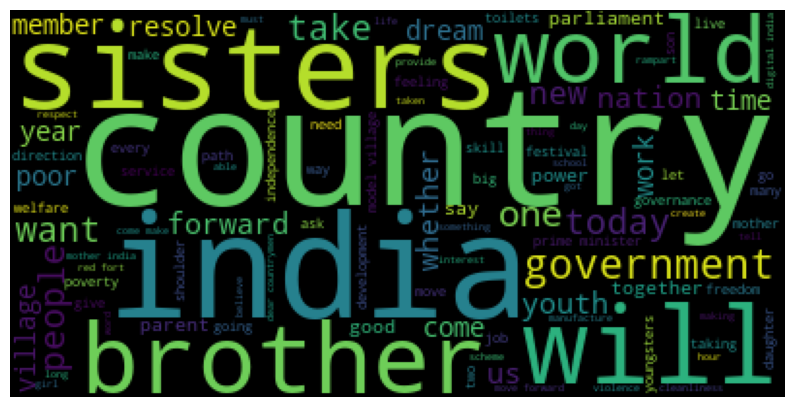

In [7]:
plt.figure(figsize=(10,6))

cloud = WordCloud(background_color = "black", max_words = 100,  stopwords = set(STOPWORDS))
cloud.generate(dataset)
#cloud.to_file("wordCloud.png")
plt.axis("off")
plt.imshow(cloud)

In [8]:
maskArray = np.array(Image.open("../../datasets/modi.png"))
cloud = WordCloud(background_color = "white", max_words = 400, mask = maskArray, stopwords = set(STOPWORDS))

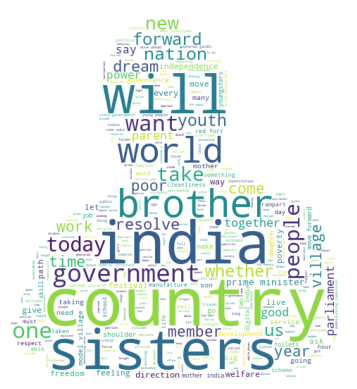

In [9]:
cloud.generate(dataset)
cloud.to_file("wordCloud.png")
plt.axis("off")
plt.imshow(cloud)
#plt.show()